# 이상 구간 뷰어 — 틱 단위 모델 (기존 방식)

`Tick_AE_fair_compare.ipynb` 와 **같은 피처 14개 / 같은 제외 규칙 / 같은 학습 방식**으로
모델을 만들고, 사이클 뷰어와 **똑같은 그림**을 그린다. 두 노트북을 나란히 놓고 비교하기 위함.

모델이 따로 저장돼 있지 않아 처음 한 번은 학습까지 한다(조기종료라 오래 걸리지 않는다).
그 뒤로는 `cache/` 에서 즉시 불러온다.

In [1]:
import os, sys, pickle
ROOT_DIR = os.path.dirname(os.getcwd())
sys.path.insert(0, ROOT_DIR); sys.path.insert(0, os.getcwd())

import numpy as np, pandas as pd, torch, joblib
import matplotlib.pyplot as plt

from Log_Extractor import LogExtractor
import Anomaly_Viewer as V

pd.set_option("display.width", 200)

In [2]:
PUMP_ID, TANK_ID, ROBOT_ID = "P1", "P1", "RB1"
START = "2026-09-10T07:00:00Z"
END = "2026-09-23T18:00:00Z"   # 고정
FORCE_REFRESH = False

CACHE = V.cache_path(f"viewer_tick_{PUMP_ID}.pkl")
TRAIN_END = pd.Timestamp("2026-09-18 16:00:00")    # KST, 이 이전이 학습 구간

DAILY_EXCLUDE_START = pd.Timestamp("23:50").time()
DAILY_EXCLUDE_END = pd.Timestamp("07:00").time()

TAGS = [f"Pump_BuildUp_{PUMP_ID}", f"{ROBOT_ID}_Robot_Num", f"g_s_SV_{PUMP_ID}",
        f"Ana_Out_{PUMP_ID}", f"Scale_Out___PT_{PUMP_ID}", f"Scale_Out___FT_{PUMP_ID}",
        f"TK_Temp_PV_{TANK_ID}", f"Hz_Out_{PUMP_ID}", "AL_Line_Bit"]

In [3]:
def prepare_tick_features(raw_df, pump_id, tank_id, robot_id):
    """Tick_AE_fair_compare.ipynb 와 동일한 14피처 + 동일한 제외 규칙."""
    df = raw_df.ffill().fillna(0).copy()
    r = df.reset_index()
    tag_SV, tag_Ana = f"g_s_SV_{pump_id}", f"Ana_Out_{pump_id}"
    tag_PT, tag_FT = f"Scale_Out___PT_{pump_id}", f"Scale_Out___FT_{pump_id}"
    tag_Temp, tag_BU = f"TK_Temp_PV_{tank_id}", f"Pump_BuildUp_{pump_id}"
    tag_Wag = f"{robot_id}_Robot_Num"

    r["Wagon_Block_ID"] = ((r[tag_Wag].diff() != 0) | (r[tag_BU].diff() != 0)).cumsum()
    smax = r[r[tag_BU] == 1].groupby("Wagon_Block_ID")[tag_SV].max()
    r["Prev_SV"] = r["Wagon_Block_ID"].map(smax.shift(1).fillna(0)).ffill().fillna(0)
    r["Prev_SV_Diff"] = r[tag_SV] - r["Prev_SV"]
    r["Phase_Transition"] = np.where(r[tag_SV].diff().fillna(0) != 0, 1.0, 0.0)
    r["Rolling_PT_Max_3"] = r[tag_PT].rolling(3, min_periods=1).max()
    r["Rolling_PT_Diff_3"] = r[tag_PT].diff(2).fillna(0)

    m = r[r[tag_BU] == 1].copy()
    m["Tick_Index"] = m.groupby("Wagon_Block_ID").cumcount()
    m["Phase_Start"] = np.where(m["Tick_Index"] < 2, 1.0, 0.0)
    m["Phase_Steady"] = np.where(m["Tick_Index"] >= 2, 1.0, 0.0)
    err = m[tag_SV] - m[tag_FT]
    m["Instant_FT_Error_Rate"] = np.where(m[tag_SV] > 0, err / m[tag_SV] * 100, 0)
    m["Cum_FT_Error"] = m.groupby("Wagon_Block_ID").apply(
        lambda g: (g[tag_SV] - g[tag_FT]).cumsum()).reset_index(level=0, drop=True)

    time_col = m[m.columns[0]]
    tod = pd.to_datetime(time_col).dt.time
    night = (tod >= DAILY_EXCLUDE_START) | (tod <= DAILY_EXCLUDE_END)
    alarm = m["AL_Line_Bit"] > 0 if "AL_Line_Bit" in m.columns else pd.Series(False, index=m.index)
    m = m[~(night.values | alarm.values | (m["Prev_SV"] == 0).values)]

    fcols = [tag_SV, "Prev_SV", "Prev_SV_Diff", tag_Ana, tag_Temp, tag_PT,
             "Rolling_PT_Max_3", "Rolling_PT_Diff_3", tag_FT,
             "Instant_FT_Error_Rate", "Cum_FT_Error",
             "Phase_Start", "Phase_Steady", "Phase_Transition"]
    m = m.fillna(0).rename(columns={m.columns[0]: "Time"})
    return m, fcols

print("준비 완료")

준비 완료


In [4]:
from sklearn.preprocessing import StandardScaler
import torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from Pump_AE import PumpAutoencoder

if (not FORCE_REFRESH) and os.path.exists(CACHE):
    with open(CACHE, "rb") as f:
        store = pickle.load(f)
    print(f"캐시에서 로드: {CACHE}")
else:
    print("DB 추출 + 학습 (처음 한 번만)...")
    ex = LogExtractor(env_path=os.path.join(ROOT_DIR, ".env"))
    raw = ex.get_data(start_time=START, end_time=END, target_tags=TAGS)
    feats, FCOLS = prepare_tick_features(raw, PUMP_ID, TANK_ID, ROBOT_ID)

    tr_mask = pd.to_datetime(feats["Time"]) < TRAIN_END
    scaler = StandardScaler().fit(feats.loc[tr_mask, FCOLS])
    Xtr = scaler.transform(feats.loc[tr_mask, FCOLS])
    Xall = scaler.transform(feats[FCOLS])

    torch.manual_seed(42)
    model = PumpAutoencoder(len(FCOLS))
    opt = optim.Adam(model.parameters(), lr=0.0005)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=5)
    crit = nn.MSELoss()
    # 학습 구간의 뒤 10% 를 검증으로 떼어 조기종료에만 쓴다
    cut = int(len(Xtr) * 0.9)
    dl = DataLoader(TensorDataset(torch.FloatTensor(Xtr[:cut]), torch.FloatTensor(Xtr[:cut])),
                    batch_size=256, shuffle=True)
    vx = torch.FloatTensor(Xtr[cut:])
    best, wait, best_state = float("inf"), 0, None
    for ep in range(1, 101):
        model.train()
        for xb, yb in dl:
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            va = crit(model(vx), vx).item()
        sch.step(va)
        if va < best - 1e-5:
            best, wait, best_state = va, 0, {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
        if ep % 10 == 0 or ep == 1:
            print(f"  epoch {ep:03d} | valid {va:.4f}")
        if wait >= 15:
            print(f"  조기종료 (epoch {ep})"); break
    model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        t = torch.FloatTensor(Xall)
        pf = ((t - model(t)) ** 2).numpy()
    feats = feats.copy()
    feats["Recon_Error"] = pf.mean(axis=1)

    store = {"feats": feats, "per_feat": pf, "raw": raw, "fcols": FCOLS}
    with open(CACHE, "wb") as f:
        pickle.dump(store, f)
    print(f"캐시 저장: {CACHE}")

feats, per_feat, raw, FCOLS = store["feats"], store["per_feat"], store["raw"], store["fcols"]

tr_mask = pd.to_datetime(feats["Time"]) < TRAIN_END
THRESHOLD = float(np.percentile(feats.loc[tr_mask, "Recon_Error"], 99))
print(f"\n틱 {len(feats):,}개 | 임계치 {THRESHOLD:.4f} | "
      f"이상 {int((feats['Recon_Error']>THRESHOLD).sum()):,}건 "
      f"({(feats['Recon_Error']>THRESHOLD).mean()*100:.2f}%)")

DB 추출 + 학습 (처음 한 번만)...
🔌 [Extractor] InfluxDB 분석용 추출기 연결 완료!
🚀 추출 시작: 2026-09-10T07:00:00+00:00 ~ 2026-09-23T05:20:20.449833+00:00
   태그 9개 · 앞쪽 600초는 결측 복원용으로 더 받습니다
📦 [Chunk] 2026-09-10T06:50:00Z ~ 2026-09-10T12:50:00Z ... 

39314행
📦 [Chunk] 2026-09-10T12:50:00Z ~ 2026-09-10T18:50:00Z ... 

35937행
📦 [Chunk] 2026-09-10T18:50:00Z ~ 2026-09-11T00:50:00Z ... 

37014행
📦 [Chunk] 2026-09-11T00:50:00Z ~ 2026-09-11T06:50:00Z ... 

38124행
📦 [Chunk] 2026-09-11T06:50:00Z ~ 2026-09-11T12:50:00Z ... 

...

  epoch 070 | valid 0.0814


  epoch 080 | valid 0.0811


  epoch 090 | valid 0.0813


  epoch 100 | valid 0.0812


캐시 저장: C:\Users\taetk\Documents\KTA_Train\parkkt\cache\viewer_tick_P1.pkl

틱 506,796개 | 임계치 0.5592 | 이상 4,914건 (0.97%)


## 1. 날짜 x 시간 히트맵

사이클 뷰어와 **같은 축, 같은 색 기준**이다. 나란히 놓고 비교하면 된다.

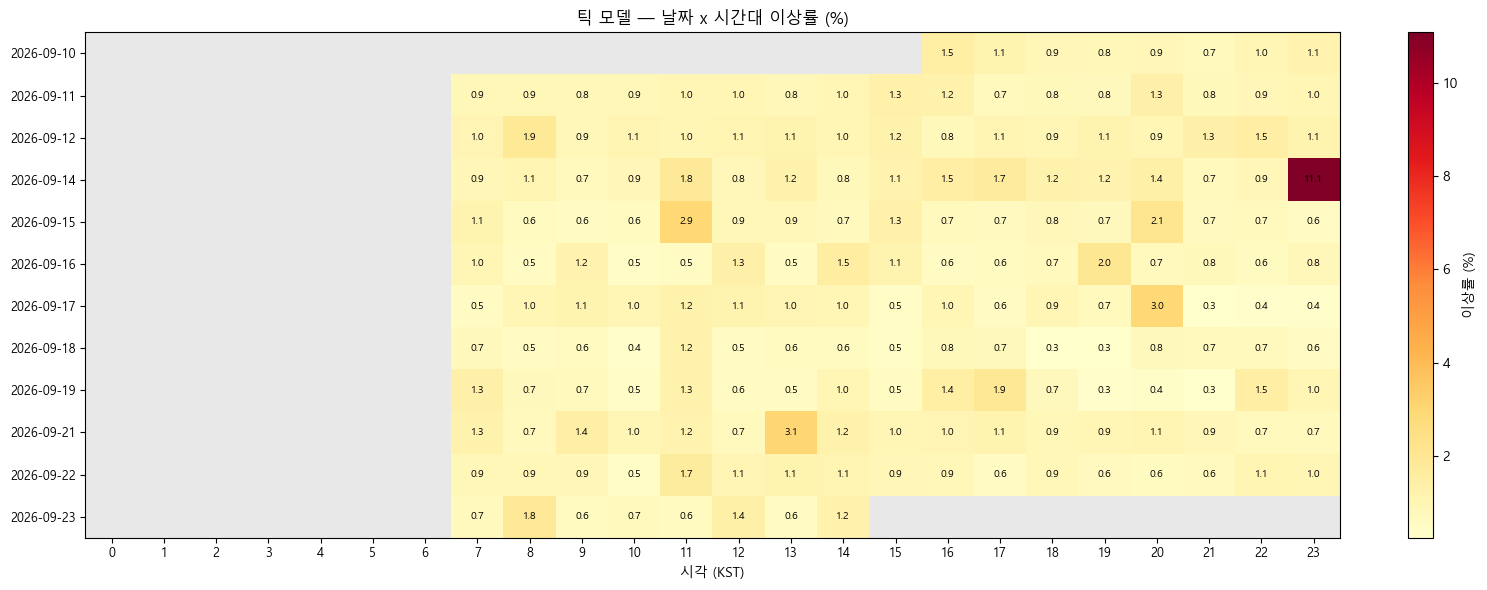

In [5]:
fig, piv_rate = V.hourly_heatmap(feats, THRESHOLD, time_col="Time",
                                  title="틱 모델 — 날짜 x 시간대 이상률 (%)")
plt.show()

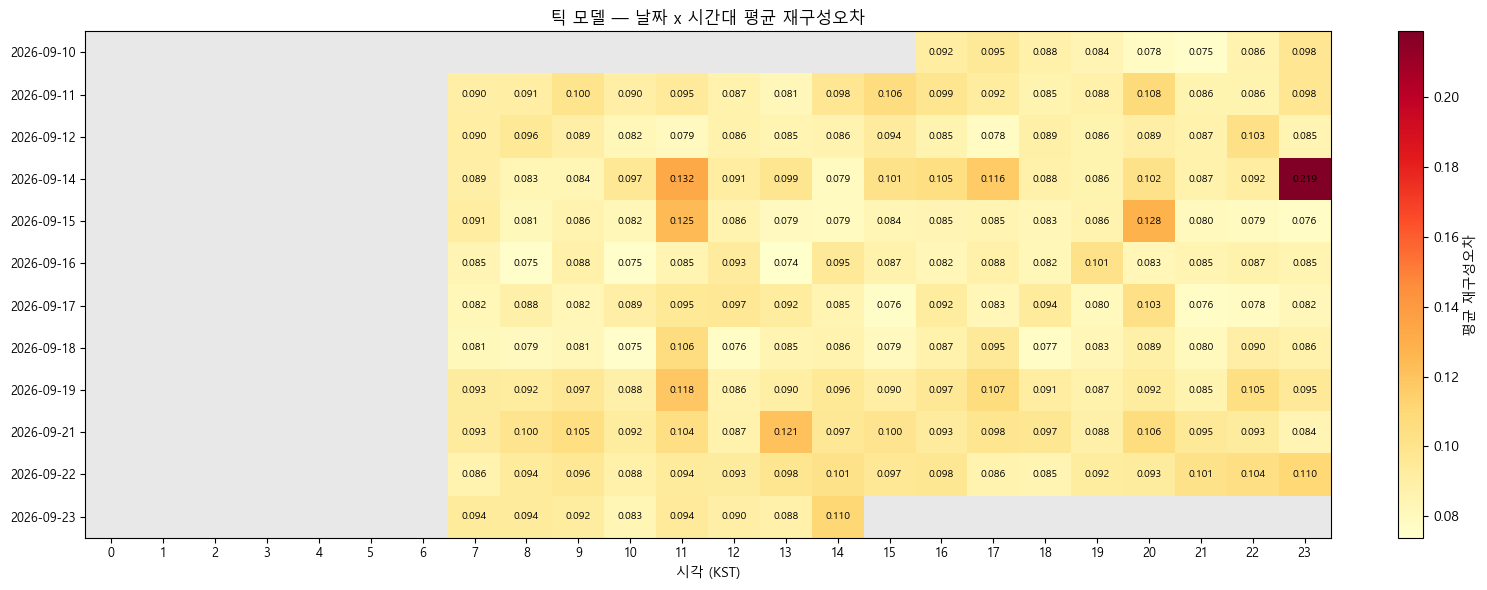

In [6]:
fig, piv_mean = V.hourly_heatmap(feats, THRESHOLD, time_col="Time", value="mean",
                                  title="틱 모델 — 날짜 x 시간대 평균 재구성오차")
plt.show()

In [7]:
d = V.add_time_cols(feats, "Time")
d["is_anom"] = d["Recon_Error"] > THRESHOLD
daily = d.groupby("Date").agg(틱수=("Recon_Error", "size"), 이상건수=("is_anom", "sum"),
                              평균오차=("Recon_Error", "mean"), 최대오차=("Recon_Error", "max"))
daily["이상률%"] = (daily["이상건수"] / daily["틱수"] * 100).round(2)
print(daily.round(4).to_string())

               틱수  이상건수    평균오차    최대오차  이상률%
Date                                         
2026-09-10  21508   222  0.0871  1.9568  1.03
2026-09-11  45175   426  0.0927  2.1020  0.94
2026-09-12  50493   563  0.0879  2.9619  1.12
2026-09-14  45491   665  0.0992  2.6908  1.46
2026-09-15  45239   411  0.0865  3.8292  0.91
2026-09-16  45725   397  0.0850  2.2465  0.87
2026-09-17  46232   407  0.0865  2.0751  0.88
2026-09-18  43747   269  0.0837  1.9430  0.61
2026-09-19  47817   415  0.0942  3.1411  0.87
2026-09-21  46047   510  0.0973  2.1700  1.11
2026-09-22  51173   457  0.0951  1.8275  0.89
2026-09-23  18149   172  0.0920  2.2875  0.95


## 2. 문제가 있는 날 하루 펼쳐보기

대상 날짜: 2026-09-14


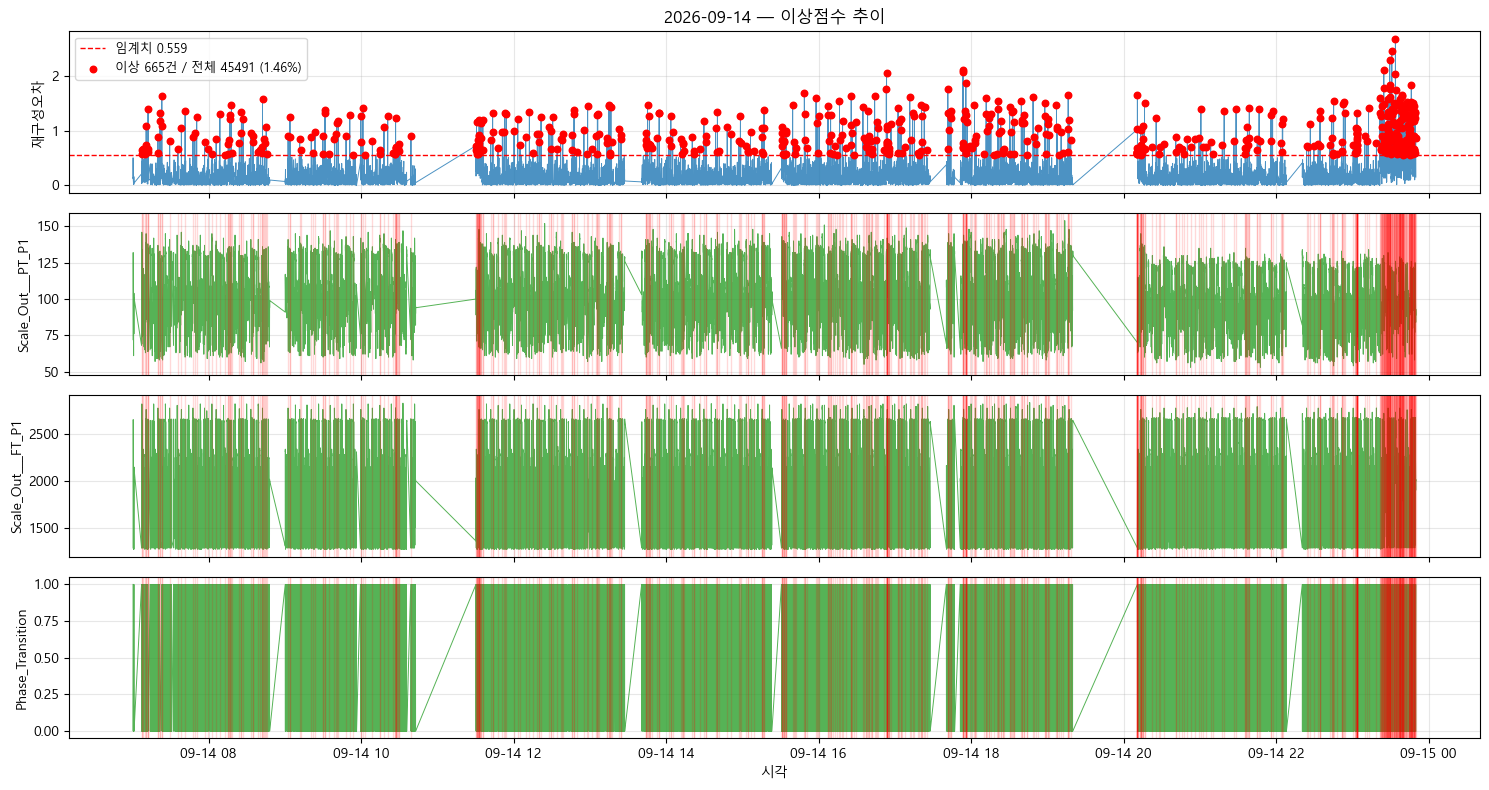

In [8]:
TARGET_DATE = daily.sort_values("이상률%", ascending=False).index[0]
print(f"대상 날짜: {TARGET_DATE}")
V.daily_detail(feats, TARGET_DATE, THRESHOLD, time_col="Time",
               extra_cols=[f"Scale_Out___PT_{PUMP_ID}", f"Scale_Out___FT_{PUMP_ID}",
                           "Phase_Transition"])
plt.show()

## 3. 피처 기여도 히트맵

사이클 모델과 비교해서 보자 — 여기서는 `Phase_Transition`(SV 변경) 이 얼마나 자주
범인으로 나오는지가 관전 포인트다.

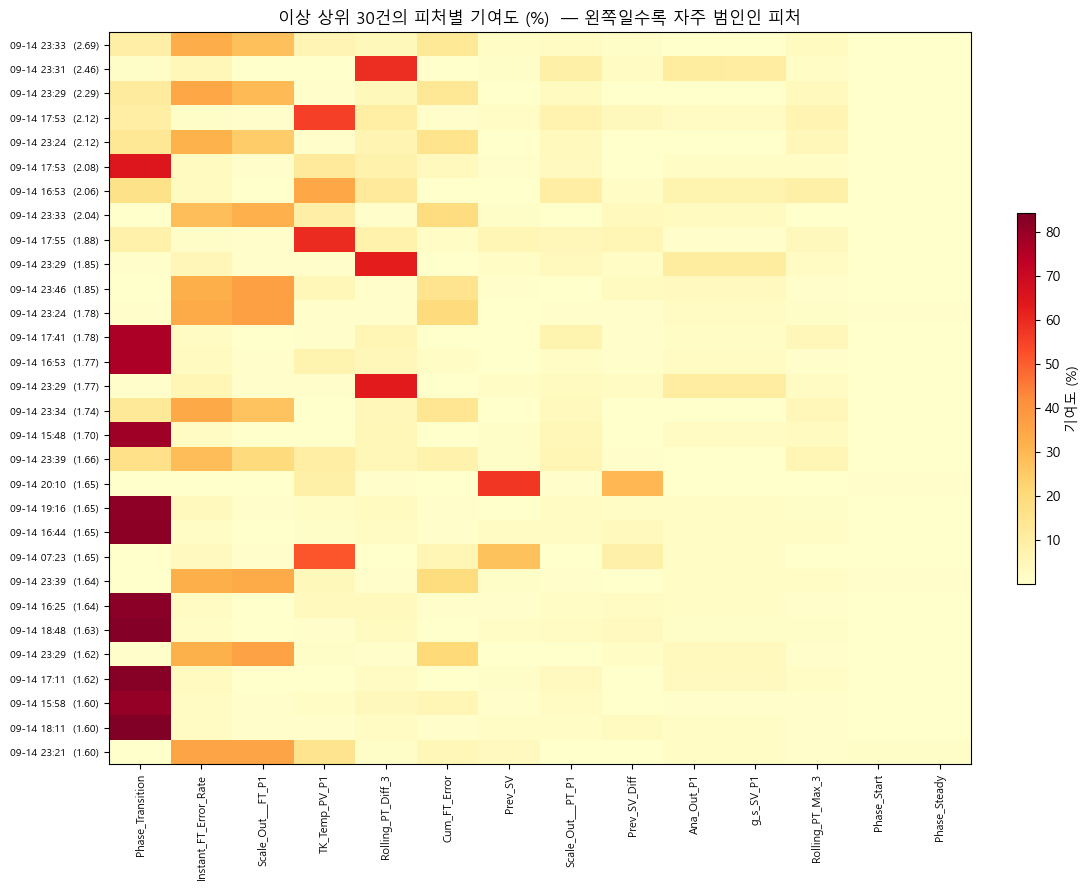

평균 기여도 상위
Phase_Transition         32.5
Instant_FT_Error_Rate    13.5
Scale_Out___FT_P1        11.5
TK_Temp_PV_P1             9.8
Rolling_PT_Diff_3         9.5
Cum_FT_Error              6.1
Prev_SV                   3.8
Scale_Out___PT_P1         2.9
Prev_SV_Diff              2.8
Ana_Out_P1                2.6


In [9]:
day_mask = (pd.to_datetime(feats["Time"]).dt.date == pd.to_datetime(TARGET_DATE).date()).values
fig, contrib = V.contribution_heatmap(
    per_feat[day_mask], FCOLS, feats.loc[day_mask, "Recon_Error"].values,
    feats.loc[day_mask, "Time"].values, THRESHOLD, top_n=30, figsize=(11, 9))
plt.show()
if contrib is not None:
    print("평균 기여도 상위")
    print(contrib.mean().sort_values(ascending=False).head(10).round(1).to_string())

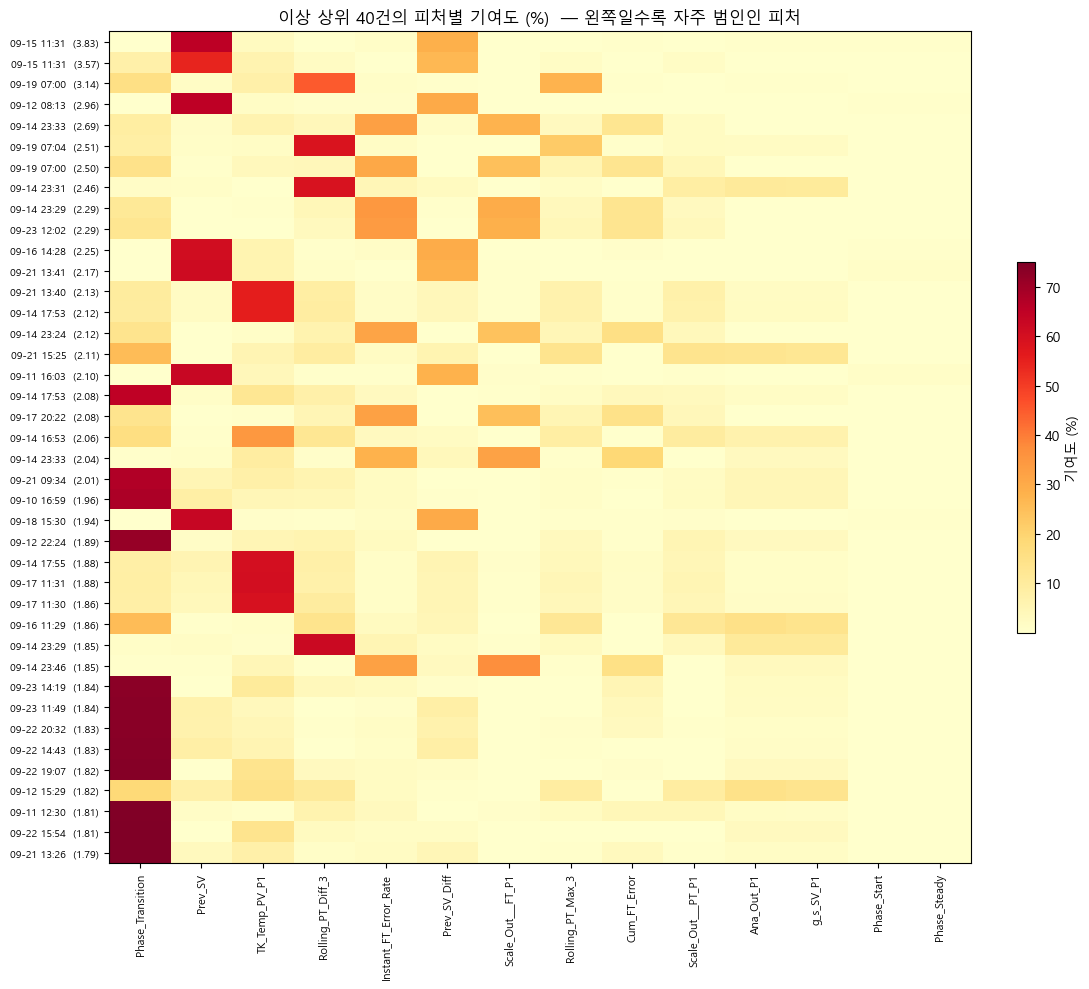

In [10]:
fig, contrib_all = V.contribution_heatmap(
    per_feat, FCOLS, feats["Recon_Error"].values, feats["Time"].values,
    THRESHOLD, top_n=40, figsize=(11, 10))
plt.show()

## 4. 개별 이상 시점 원본 확대

In [11]:
worst = feats[feats["Recon_Error"] > THRESHOLD].sort_values("Recon_Error", ascending=False)
print(worst[["Time", "Recon_Error", f"g_s_SV_{PUMP_ID}", f"Scale_Out___PT_{PUMP_ID}",
             f"Scale_Out___FT_{PUMP_ID}", "Phase_Transition"]].head(10).to_string(index=False))

                      Time  Recon_Error  g_s_SV_P1  Scale_Out___PT_P1  Scale_Out___FT_P1  Phase_Transition
2026-09-15 11:31:51.982063     3.829224     2300.0              103.0             1285.0               0.0
2026-09-15 11:31:51.445888     3.572662     2300.0              102.0             1285.0               1.0
2026-09-19 07:00:41.670389     3.141062     2010.0               64.0             1271.0               1.0
2026-09-12 08:13:34.489919     2.961886     2260.0              107.0             1344.0               0.0
2026-09-14 23:33:53.207053     2.690812     2740.0              123.0             2717.0               1.0
2026-09-19 07:04:51.300436     2.505625     2300.0               57.0             1285.0               1.0
2026-09-19 07:00:31.145209     2.496438     2680.0              130.0             2603.0               1.0
2026-09-14 23:31:02.582619     2.462634     2680.0               63.0             1300.0               0.0
2026-09-14 23:29:24.386073     2.2921


=== #1  2026-09-15 11:31:51.982063  오차 3.829 ===
   Prev_SV: 65.5%
   Prev_SV_Diff: 28.6%
   TK_Temp_PV_P1: 2.5%


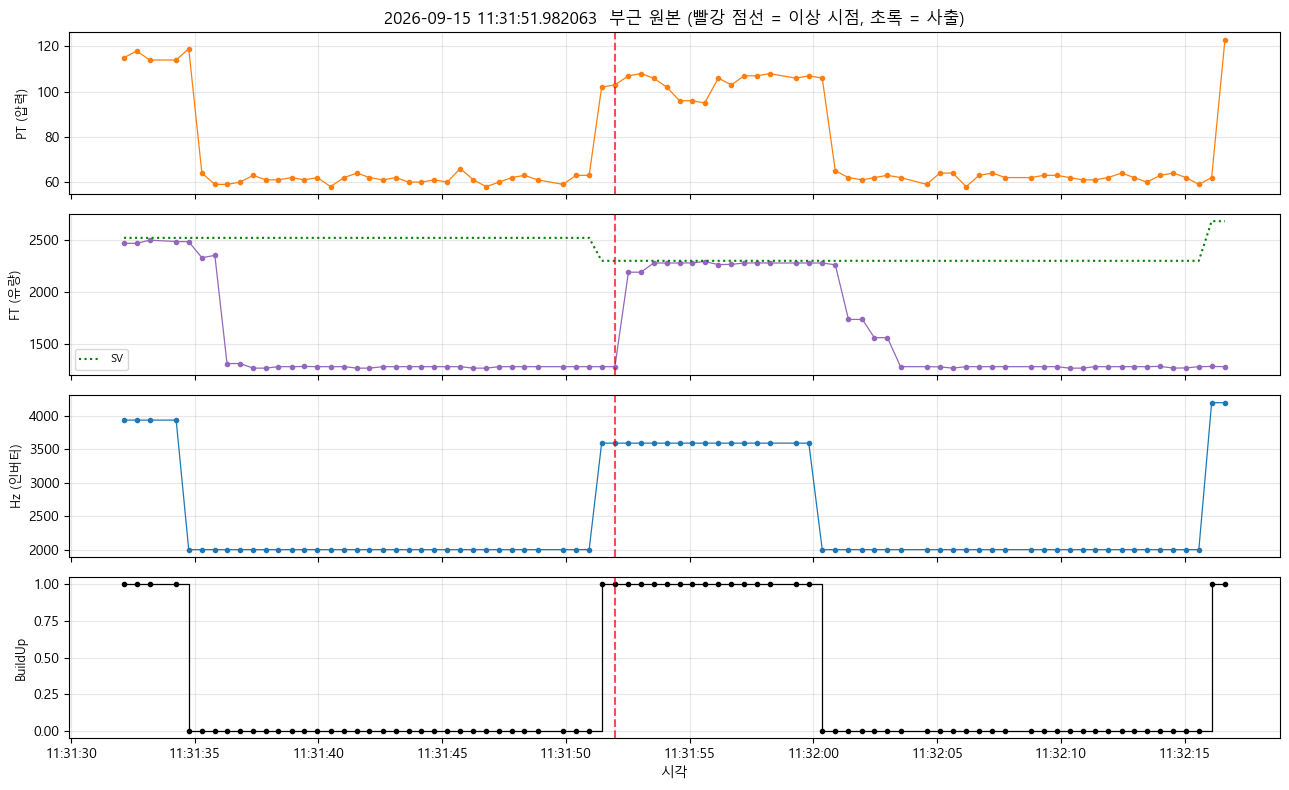


=== #2  2026-09-15 11:31:51.445888  오차 3.573 ===
   Prev_SV: 54.5%
   Prev_SV_Diff: 26.5%
   Phase_Transition: 7.5%


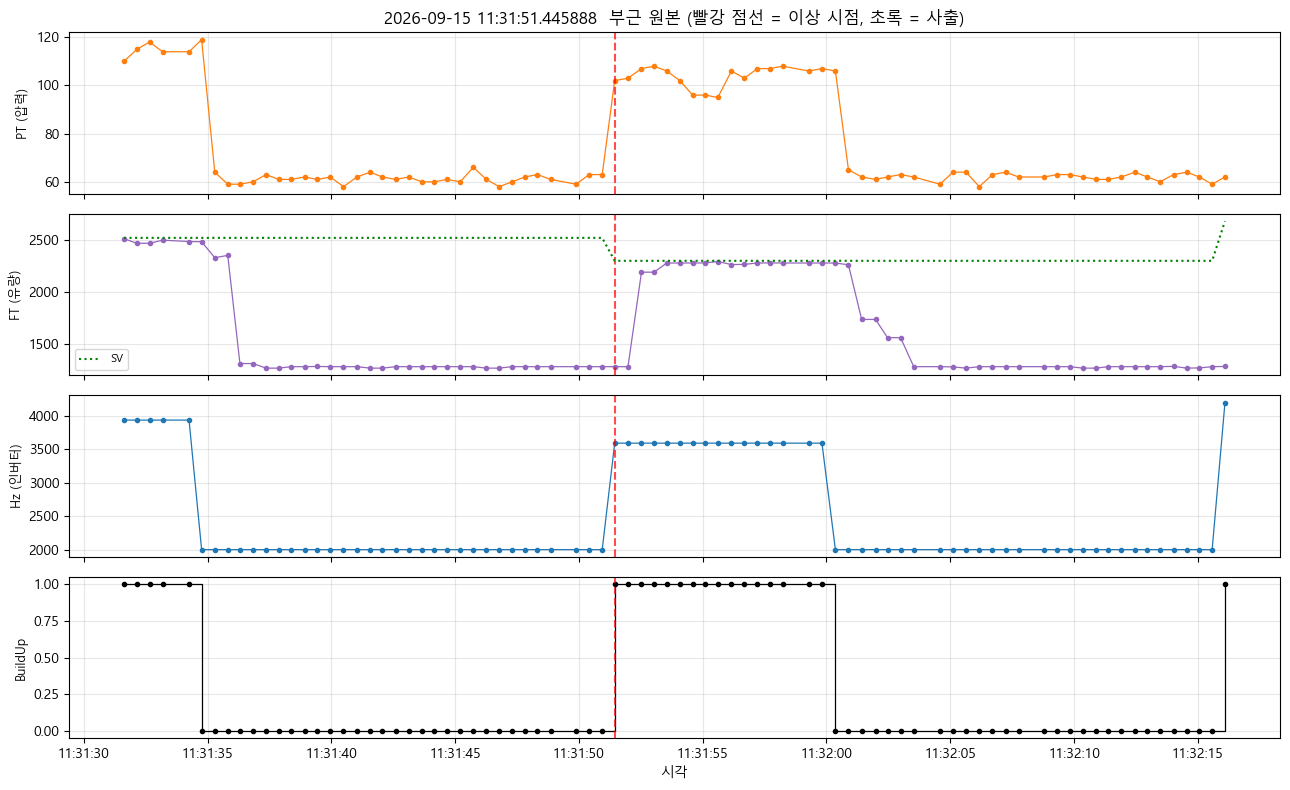


=== #3  2026-09-19 07:00:41.670389  오차 3.141 ===
   Rolling_PT_Diff_3: 44.9%
   Rolling_PT_Max_3: 27.8%
   Phase_Transition: 15.3%


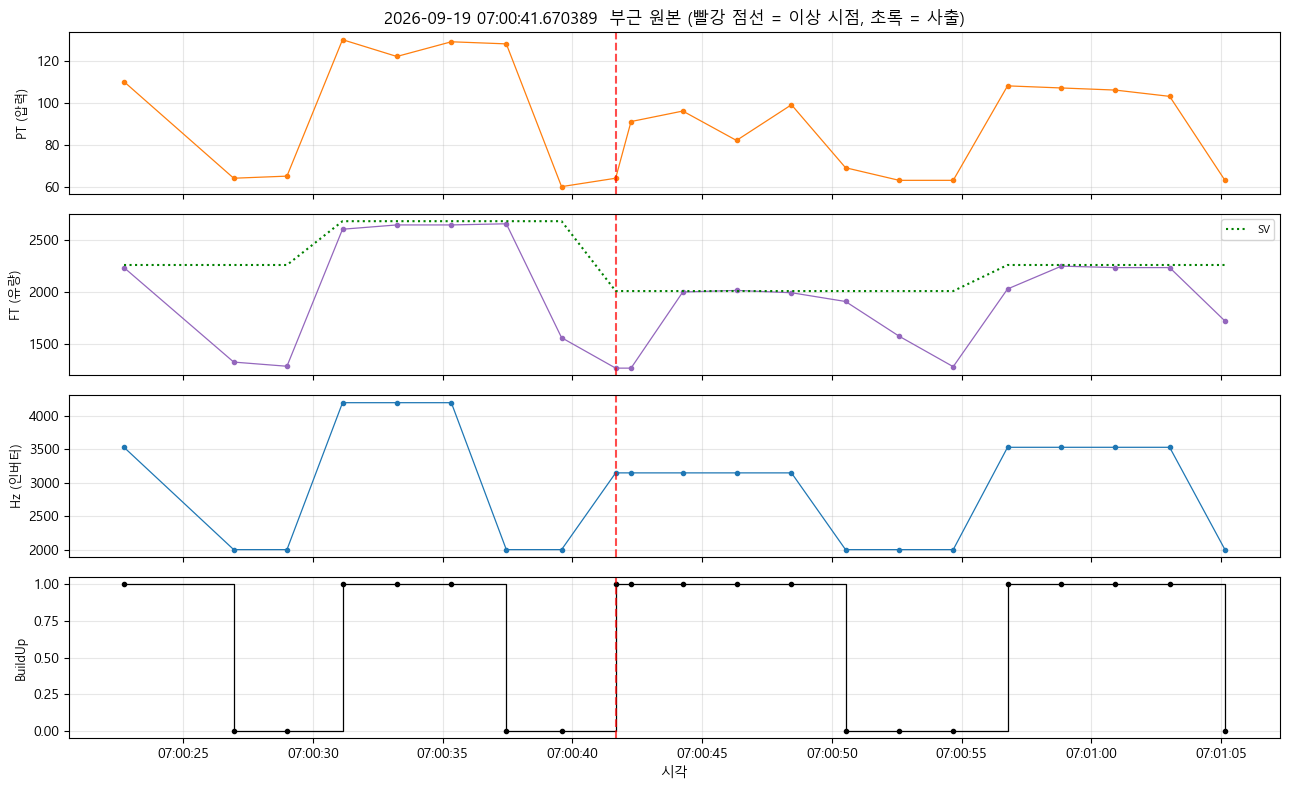

In [12]:
N_ZOOM = 3
for i in range(min(N_ZOOM, len(worst))):
    row = worst.iloc[i]
    pos = feats.index.get_indexer([worst.index[i]])[0]
    print(f"\n=== #{i+1}  {row['Time']}  오차 {row['Recon_Error']:.3f} ===")
    contrib = pd.Series(per_feat[pos], index=FCOLS)
    contrib = (contrib / contrib.sum() * 100).sort_values(ascending=False)
    for f_, v in contrib.head(3).items():
        print(f"   {f_}: {v:.1f}%")
    V.zoom_raw(raw, row["Time"], PUMP_ID, before_sec=20, after_sec=25)
    plt.show()